# 005 Persistence

这是 LangGraph 学习线的第五份 Notebook。

官方参考：

- https://docs.langchain.com/oss/python/langgraph/persistence

学习目标：

1. 理解 persistence 为什么是 LangGraph 的核心能力
2. 理解 thread、checkpoint、state snapshot 的关系
3. 学会用 `InMemorySaver` 保存 graph 执行状态
4. 学会使用 `get_state`、`get_state_history`、`update_state`
5. 对比 LangGraph checkpoint 和本仓库 Harness approval run state

这一讲使用内存 checkpointer，不需要数据库。生产环境应使用持久化 checkpointer。

## 1. Persistence 解决什么问题

如果 agent 只是一次函数调用，状态可以存在内存变量里。

但真实 agent 经常是长运行任务：

- 调用了多个工具
- 中间需要人工审批
- 需要流式输出
- 可能失败后重试
- 需要回看历史状态

这时必须有 persistence。

LangGraph 的 persistence 核心是：

```text
每次 graph 运行到一个 super-step，都可以保存 checkpoint。
checkpoint 通过 thread_id 归属到某个会话/任务。
```

## 2. 三个核心概念

| 概念 | 含义 |
| --- | --- |
| thread | 一条独立会话或任务实例 |
| checkpoint | 某个时间点保存下来的 graph state |
| state snapshot | 读取 checkpoint 后得到的状态快照 |

可以用 Java 类比：

```text
thread_id 像 workflowInstanceId。
checkpoint 像 workflow 执行到某一步时落库的快照。
state snapshot 像从库里读出来的当前执行上下文。
```

In [73]:
from operator import add
from typing import Annotated

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict


## 3. 定义一个最小 State

这个 state 有两个字段：

- `foo`：普通字符串，每次更新会覆盖旧值
- `bar`：列表，使用 `Annotated[..., add]`，每次更新会追加

In [74]:
class PersistenceState(TypedDict):
    foo: str
    bar: Annotated[list[str], add]


def node_a(state: PersistenceState) -> dict:
    return {
        "foo": "a",
        "bar": ["node_a"],
    }


def node_b(state: PersistenceState) -> dict:
    return {
        "foo": "b",
        "bar": ["node_b"],
    }


## 4. 编译 graph 时传入 checkpointer

关键点在这里：

```python
graph = builder.compile(checkpointer=checkpointer)
```

没有 checkpointer，graph 仍然能运行，但不会保存可恢复的 checkpoint。

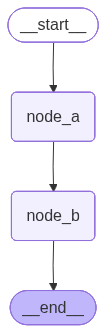

In [76]:
builder = StateGraph(PersistenceState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
persistent_graph = builder.compile(checkpointer=checkpointer)
persistent_graph

## 5. 用 thread_id 执行 graph

执行带 checkpointer 的 graph 时，必须提供 `thread_id`。

它决定 checkpoint 属于哪个会话或任务实例。

In [77]:
config = {"configurable": {"thread_id": "persistence-demo"}}

result = persistent_graph.invoke(
    {
        "foo": "",
        "bar": [],
    },
    config,
)

print(result)

{'foo': 'b', 'bar': ['node_a', 'node_b']}


## 6. 读取当前 state

`get_state(config)` 会读取当前 thread 的最新 checkpoint。

返回的是 state snapshot。

In [78]:
snapshot = persistent_graph.get_state(config)

print("values:", snapshot.values)
print("next:", snapshot.next)
print("step:", snapshot.metadata.get("step"))

values: {'foo': 'b', 'bar': ['node_a', 'node_b']}
next: ()
step: 2


## 7. 读取 state history

`get_state_history(config)` 可以读取这个 thread 的 checkpoint 历史。

这就是 time travel、debug、恢复和审计的基础。

In [79]:
history = list(persistent_graph.get_state_history(config))

print("history length:", len(history))

for item in history:
    print(
        "step=", item.metadata.get("step"),
        "next=", item.next,
        "values=", item.values,
    )

history length: 4
step= 2 next= () values= {'foo': 'b', 'bar': ['node_a', 'node_b']}
step= 1 next= ('node_b',) values= {'foo': 'a', 'bar': ['node_a']}
step= 0 next= ('node_a',) values= {'foo': '', 'bar': []}
step= -1 next= ('__start__',) values= {'bar': []}


## 8. 手动更新 state

`update_state(config, values)` 可以向当前 thread 写入一个新的 checkpoint。

这在人工审批、外部系统回调、纠错恢复时很有用。

In [80]:
updated_config = persistent_graph.update_state(
    config,
    {
        "foo": "manual_update",
        "bar": ["manual_update"],
    },
)

print("updated_config:", updated_config)
print("after update:", persistent_graph.get_state(config).values)

updated_config: {'configurable': {'thread_id': 'persistence-demo', 'checkpoint_ns': '', 'checkpoint_id': '1f16313e-7438-636a-8003-4be16f79a274'}}
after update: {'foo': 'manual_update', 'bar': ['node_a', 'node_b', 'manual_update']}


## 9. thread 隔离

不同 `thread_id` 有不同 checkpoint 历史。

这和多用户、多会话、多任务实例是同一个思想。

In [81]:
other_config = {"configurable": {"thread_id": "another-thread"}}

persistent_graph.invoke(
    {
        "foo": "other",
        "bar": [],
    },
    other_config,
)

print("persistence-demo:", persistent_graph.get_state(config).values)
print("another-thread:", persistent_graph.get_state(other_config).values)

persistence-demo: {'foo': 'manual_update', 'bar': ['node_a', 'node_b', 'manual_update']}
another-thread: {'foo': 'b', 'bar': ['node_a', 'node_b']}


## 10. 和 Harness approval 恢复的关系

本仓库 Harness 目前也有 run state：

- `_runs`
- `_pending_approvals`
- `ApprovalTicket`
- `stream_resume_approval`

它和 LangGraph persistence 的对应关系：

| LangGraph | Harness |
| --- | --- |
| `thread_id` | `run_id` / session id |
| checkpoint | `ExecutionRun` 中保存的执行状态 |
| `get_state` | 查询当前 run 状态 |
| `update_state` | 审批通过后恢复执行前更新状态 |
| state history | ledger / event history |

区别是：

```text
Harness 当前是内存实现；
LangGraph persistence 提供了标准 checkpoint 机制。
```

## 11. 本讲练习

请回答：

1. 为什么带 checkpointer 的 graph 需要 `thread_id`？
2. checkpoint 和普通 Python 变量有什么区别？
3. 人工审批通过后，为什么适合用 `update_state`？
4. 为什么生产环境不应该只用 `InMemorySaver`？

参考方向：

- `thread_id` 用于区分会话或任务实例
- checkpoint 是可恢复、可查询的状态快照
- `update_state` 可以把外部审批结果写回 graph
- `InMemorySaver` 进程重启后会丢失

## 12. 本讲小结

这一讲的核心：

```text
Persistence 让 graph 从一次性函数调用，变成长运行、可恢复、可审计的任务。
```

你现在应该能看懂：

- `InMemorySaver`
- `compile(checkpointer=...)`
- `thread_id`
- `get_state`
- `get_state_history`
- `update_state`

下一讲可以继续学习 Memory。